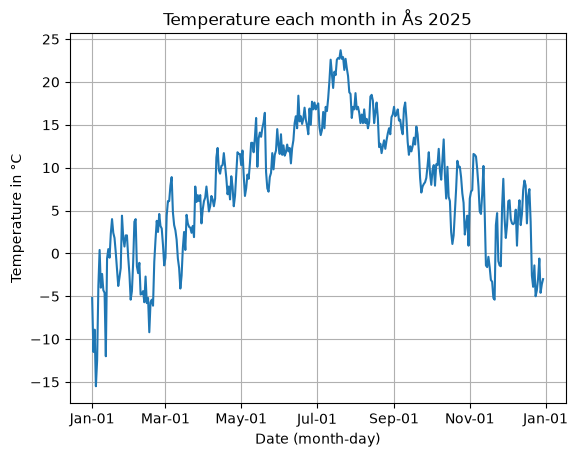

------SUMMARY TABLE 2025------
Mean temperature:      7.90 °C
Median temperature:    8.40 °C
Minimum temperature: -15.50 °C
Maximum temperature:  23.70 °C
------------------------------


In [31]:
#Main working folder

#Client id, getting started
from xmlrpc.client import _datetime

import pandas as pd 
import requests
import matplotlib.pyplot as plt

client_id = open("../frost_client_id.txt").read().strip()

#Task 1: Temperature: 
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
'sources': 'SN17850',
'elements': 'mean(air_temperature P1D)',
'referencetime': '2025-01-01/2025-12-31',
}

# Get data from frost.met.no
response = requests.get(endpoint, parameters, auth=(client_id, ''))
assert response.status_code == 200

# convert response to JSON-format
data = response.json()

temperature_data = []
for day in data['data']:
    dato = pd.Timestamp(day['referenceTime'])
    temp = day['observations'][0]['value']
    temperature_data.append((dato, temp))

dataframe = pd.DataFrame(temperature_data, columns=['Date', 'Temperature'])
dataframe.set_index('Date', inplace=True)

# show month and day on x-axis, date is given as the first of each month.
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b-%d'))

# plotting data.
plt.plot(dataframe.index, dataframe['Temperature'])
plt.title('Temperature each month in Ås 2025')
plt.xlabel('Date (month-day)')
plt.ylabel('Temperature in °C')
plt.grid(True)
plt.show()

# Summary table containing mean, median, min and max temperatures. 
mean = dataframe['Temperature'].mean()
median = dataframe['Temperature'].median()
minimum_temp = dataframe['Temperature'].min()
maximum_temp = dataframe['Temperature'].max()

print("------SUMMARY TABLE 2025------")
print(f"Mean temperature: {mean:9.2f} °C")
print(f"Median temperature: {median:7.2f} °C")
print(f"Minimum temperature: {minimum_temp:.2f} °C")
print(f"Maximum temperature: {maximum_temp:6.2f} °C")
print("------------------------------")


